1. Importar y Leer el DataSet

In [ ]:
!pip install datasets scikeras

In [ ]:
# =========================================================
# CONFIGURACIÓN Y UTILIDADES
# =========================================================
import os
import warnings
import joblib

warnings.filterwarnings("ignore")

from google.colab import userdata

# =========================================================
# MANEJO DE DATOS
# =========================================================
import numpy as np
import pandas as pd

from datasets import load_dataset

# =========================================================
# VISUALIZACIÓN
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots

# =========================================================
# ESTADÍSTICA
# =========================================================
from scipy import stats

# =========================================================
# MACHINE LEARNING - PREPROCESAMIENTO
# =========================================================
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    PolynomialFeatures,
    LabelEncoder
)

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    cross_validate,
    StratifiedKFold
)

from imblearn.over_sampling import SMOTE

# =========================================================
# MODELOS MACHINE LEARNING
# =========================================================
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    RidgeCV,
    Lasso,
    LassoCV,
    ElasticNet,
    ElasticNetCV,
    LogisticRegression
)

from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier
)

from xgboost import XGBClassifier

# =========================================================
# DEEP LEARNING
# =========================================================
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import load_model
from tensorflow.keras import regularizers

# =========================================================
# MÉTRICAS
# =========================================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

# =========================================================
# VISUALIZACIÓN ML
# =========================================================
from yellowbrick.regressor import (
    ResidualsPlot,
    PredictionError
)

# =========================================================
# EXPLICABILIDAD
# =========================================================
import shap

In [ ]:
from datasets import load_dataset

#https://huggingface.co/datasets/CiferAI/Cifer-Fraud-Detection-Dataset-AF
dataset = load_dataset("CiferAI/Cifer-Fraud-Detection-Dataset-AF", token=userdata.get("HF_API_KEY"))
#
dataset

DatasetDict({
    train: Dataset({
        features: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud'],
        num_rows: 21000000
    })
})

Mantener todos los fraudes y una muestra de no fraudes

In [ ]:


data_df = dataset["train"].to_pandas()

# Separar clases
fraud = data_df[data_df["isFraud"] == 1]
no_fraud = data_df[data_df["isFraud"] == 0]

# Ratio deseado (5:1)
ratio = 5

no_fraud_sample = no_fraud.sample(
    n=len(fraud) * ratio,
    random_state=42
)

# Unir y mezclar
data_df = pd.concat([
    fraud,
    no_fraud_sample
]).sample(frac=1, random_state=42)

print(data_df.shape)
print(data_df["isFraud"].value_counts())
print(data_df["isFraud"].value_counts(normalize=True) * 100)

(164820, 11)
isFraud
0    137350
1     27470
Name: count, dtype: int64
isFraud
0    83.333333
1    16.666667
Name: proportion, dtype: float64


In [ ]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 164820 entries, 7834184 to 19322691
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            164820 non-null  int64  
 1   type            164820 non-null  object 
 2   amount          164820 non-null  float64
 3   nameOrig        164820 non-null  object 
 4   oldbalanceOrg   164820 non-null  float64
 5   newbalanceOrig  164820 non-null  float64
 6   nameDest        164820 non-null  object 
 7   oldbalanceDest  164820 non-null  float64
 8   newbalanceDest  164820 non-null  float64
 9   isFraud         164820 non-null  int64  
 10  isFlaggedFraud  164820 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 15.1+ MB


In [ ]:
data_df.head(-10)
# df.sample(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
7834184,76,PAYMENT,579164.97,C94709239,14701.62,2570.71,C340285967,211972.55,16339.92,0,0
3610057,1,PAYMENT,22767.05,C1730337646,169338.01,47693.31,C83754602,618631.95,0.00,1,0
11653249,367,PAYMENT,61395.72,sdv-pii-h0fbo,714.57,1147988.79,sdv-pii-gtp49,656300.95,1260.19,1,0
495325,83,CASH_OUT,31016.60,sdv-pii-ocaab,0.77,1387031.12,sdv-pii-3nl7x,2743575.11,2085.99,0,0
10420489,348,PAYMENT,148992.90,sdv-pii-95ivh,94008.66,379396.39,sdv-pii-ji5h0,83555.57,1399.17,0,0
...,...,...,...,...,...,...,...,...,...,...,...
14997339,338,CASH_IN,215755.74,C1926746081,386407.66,7963836.85,C739234242,4434173.60,7056101.18,0,0
18634037,147,CASH_OUT,116831.71,C536804056,1941041.00,2990395.58,C1219335786,1396605.45,768662.39,0,0
5259565,263,CASH_IN,438330.47,C798426753,1753.47,2529194.97,C155029781,6429603.53,953592.96,0,0
12243255,165,DEBIT,153029.31,sdv-pii-f1itq,4228979.72,5858065.07,sdv-pii-bdq2l,2917675.39,7839629.24,1,0


In [ ]:
data_df.tail(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
7828660,250,PAYMENT,8147.08,C1024230259,15.01,5116.43,M1821295729,6796.01,0.00,0,0
2090130,108,PAYMENT,42379.45,C197756353,4513491.85,157608.25,M1110103111,688.03,0.00,0,0
7765332,324,CASH_IN,21067.54,C1014042946,71561.86,507445.27,M1653078391,916462.89,237.82,0,0
6664956,106,CASH_OUT,133640.92,C906166308,153.06,348297.18,C532593878,905723.89,7102.12,0,0
4113981,124,CASH_OUT,197122.42,C1635042671,32604.35,570488.61,C1530421689,1586460.54,9747.05,0,0
9856767,238,CASH_IN,364611.29,sdv-pii-yhbg1,2554955.14,942182.93,sdv-pii-62ovz,2529699.13,23399259.50,0,0
1042396,134,PAYMENT,156404.87,sdv-pii-eqz6e,14497.44,1457148.90,sdv-pii-yio8n,2370550.61,830127.02,0,0
19504213,9,CASH_OUT,173963.29,C781535696,1317723.91,4212504.71,C1694262384,4432139.71,1956.01,0,0
2873883,56,CASH_IN,217898.91,C231799541,229102.96,1927274.02,C155169291,2634444.39,7934.97,0,0
19322691,170,CASH_OUT,63.67,C1622051533,4493941.84,4605073.77,M1202106435,66864.40,818.08,0,0


In [ ]:
data_df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,164820.000000,1.648200e+05,1.648200e+05,1.648200e+05,1.648200e+05,1.648200e+05,164820.000000,164820.000000
mean,239.620610,1.803124e+05,1.338873e+06,2.079169e+06,1.927447e+06,3.701053e+06,0.166667,0.000006
std,163.449625,2.531626e+05,2.553572e+06,3.401453e+06,2.485516e+06,1.022596e+07,0.372679,0.002463
min,1.000000,0.000000e+00,1.000000e-02,0.000000e+00,1.000000e-02,0.000000e+00,0.000000,0.000000
25%,112.000000,1.880971e+04,1.086290e+04,5.906435e+04,2.744284e+05,1.003250e+02,0.000000,0.000000
50%,206.000000,8.272048e+04,2.198596e+05,5.799792e+05,1.009846e+06,6.485568e+04,0.000000,0.000000
75%,334.000000,2.400086e+05,1.442589e+06,2.597349e+06,2.618152e+06,2.004562e+06,0.000000,0.000000
max,743.000000,3.010443e+06,3.249110e+07,3.425780e+07,3.183058e+07,2.181861e+08,1.000000,1.000000


In [ ]:
data_df.describe(include='O')

,type,nameOrig,nameDest
count,164820,164820,164820
unique,5,163706,154186
top,CASH_OUT,C1386409564,C479495607
freq,58353,3,6


In [ ]:
data_df.isna().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [ ]:
data_df.duplicated()

,0
7834184,False
3610057,False
11653249,False
495325,False
10420489,False
...,...
9856767,False
1042396,False
19504213,False
2873883,False


In [ ]:
data_df.nunique()

,0
step,743
type,5
amount,163337
nameOrig,163706
oldbalanceOrg,154954
newbalanceOrig,161887
nameDest,154186
oldbalanceDest,164740
newbalanceDest,128512
isFraud,2


In [ ]:
fraud_counts = data_df["isFraud"].value_counts()

fig = px.pie(
    values=fraud_counts.values,
    names=["No Fraud", "Fraud"],
    title="Distribución de Fraudes",
    hole=0.4
)

fig.update_traces(
    textinfo="percent+label+value"
)

print(f"Total Transactions : {len(data_df):,}")
print(f"Fraud Transactions : {(data_df['isFraud']==1).sum():,}")
print(f"Fraud Rate         : {data_df['isFraud'].mean()*100:.4f}%")

fig.show()

Total Transactions : 164,820
Fraud Transactions : 27,470
Fraud Rate         : 16.6667%


In [ ]:
# Calculemos cuanto datos nulos hay, y mostremos un porcentaje de esos datos nulos si se encuentran presentes
missing_count = data_df.isnull().sum()
value_count = data_df.isnull().count()
missing_percentage = round(missing_count / value_count * 100, 2)
missing_df = pd.DataFrame({"Cuantos Nulos": missing_count, "Porcentaje": missing_percentage})
missing_df

,Cuantos Nulos,Porcentaje
step,0,0.0
type,0,0.0
amount,0,0.0
nameOrig,0,0.0
oldbalanceOrg,0,0.0
newbalanceOrig,0,0.0
nameDest,0,0.0
oldbalanceDest,0,0.0
newbalanceDest,0,0.0
isFraud,0,0.0


In [ ]:
# Estadisticas Básicas que se pueden aplicar a las columnas numéricas
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
step,164820.0,2.396206e+02,1.634496e+02,1.00,112.0000,206.000,3.340000e+02,7.430000e+02
amount,164820.0,1.803124e+05,2.531626e+05,0.00,18809.7125,82720.475,2.400086e+05,3.010443e+06
oldbalanceOrg,164820.0,1.338873e+06,2.553572e+06,0.01,10862.8950,219859.600,1.442589e+06,3.249110e+07
newbalanceOrig,164820.0,2.079169e+06,3.401453e+06,0.00,59064.3550,579979.235,2.597349e+06,3.425780e+07
oldbalanceDest,164820.0,1.927447e+06,2.485516e+06,0.01,274428.4050,1009845.800,2.618152e+06,3.183058e+07
newbalanceDest,164820.0,3.701053e+06,1.022596e+07,0.00,100.3250,64855.685,2.004562e+06,2.181861e+08
isFraud,164820.0,1.666667e-01,3.726791e-01,0.00,0.0000,0.000,0.000000e+00,1.000000e+00
isFlaggedFraud,164820.0,6.067225e-06,2.463174e-03,0.00,0.0000,0.000,0.000000e+00,1.000000e+00


## Preprocesamiento de Datos

### Limpieza y Encoding

Convertimos variables categóricas a numéricas y eliminamos columnas que no aportan valor predictivo (IDs, timestamps en formato string).

In [ ]:
# Encoding de variables categoricas
# Revisamos columnas de tipo object
print('Columnas categoricas:', data_df.select_dtypes(include='object').columns.tolist())
print('Shape original:', data_df.shape)


Columnas categoricas: ['type', 'nameOrig', 'nameDest']
Shape original: (164820, 11)


In [ ]:
df_model = data_df.copy()

# =====================================================
# ELIMINAR COLUMNAS
# =====================================================

cols_drop = [
    "nameOrig",
    "nameDest",
    "isFlaggedFraud"
]

df_model = df_model.drop(
    columns=[c for c in cols_drop if c in df_model.columns]
)

# =====================================================
# LABEL ENCODING
# =====================================================

cat_cols = df_model.select_dtypes(
    include='object'
).columns.tolist()

# Diccionario de encoders
label_encoders = {}

for col in cat_cols:

    le = LabelEncoder()

    df_model[col] = le.fit_transform(
        df_model[col].astype(str)
    )

    # Guardar encoder
    label_encoders[col] = le

    print(f'Encoded: {col}')

# =====================================================
# DATAFRAME FINAL
# =====================================================

df_labeled = df_model.copy()

print(f'\nShape final: {df_model.shape}')

df_model.head()

Encoded: type

Shape final: (164820, 8)


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
7834184,76,3,579164.97,14701.62,2570.71,211972.55,16339.92,0
3610057,1,3,22767.05,169338.01,47693.31,618631.95,0.00,1
11653249,367,3,61395.72,714.57,1147988.79,656300.95,1260.19,1
495325,83,1,31016.60,0.77,1387031.12,2743575.11,2085.99,0
10420489,348,3,148992.90,94008.66,379396.39,83555.57,1399.17,0


In [ ]:
# Seleccionar columnas numéricas
num_cols = df_model.select_dtypes(include=np.number).columns

# Excluir variables binarias/categóricas
num_cols = [col for col in num_cols if col != 'isFraud']

# Calcular filas necesarias
cols = 2
rows = int(np.ceil(len(num_cols) / cols))

# Crear subplots
fig = make_subplots(
    rows=rows,
    cols=cols,
    subplot_titles=num_cols
)

# Agregar boxplots
for i, col in enumerate(num_cols):

    row = (i // cols) + 1
    col_pos = (i % cols) + 1

    fig.add_trace(
        go.Box(
            x=df_model[col],
            name=col,
            boxpoints=False
        ),
        row=row,
        col=col_pos
    )

# Ajustar layout
fig.update_layout(
    height=300 * rows,
    width=1200,
    title="Boxplots Interactivos",
    showlegend=False,
    template="plotly_dark"  # puedes cambiarlo
)

# Mostrar
fig.show()

Output hidden; open in https://colab.research.google.com to view.

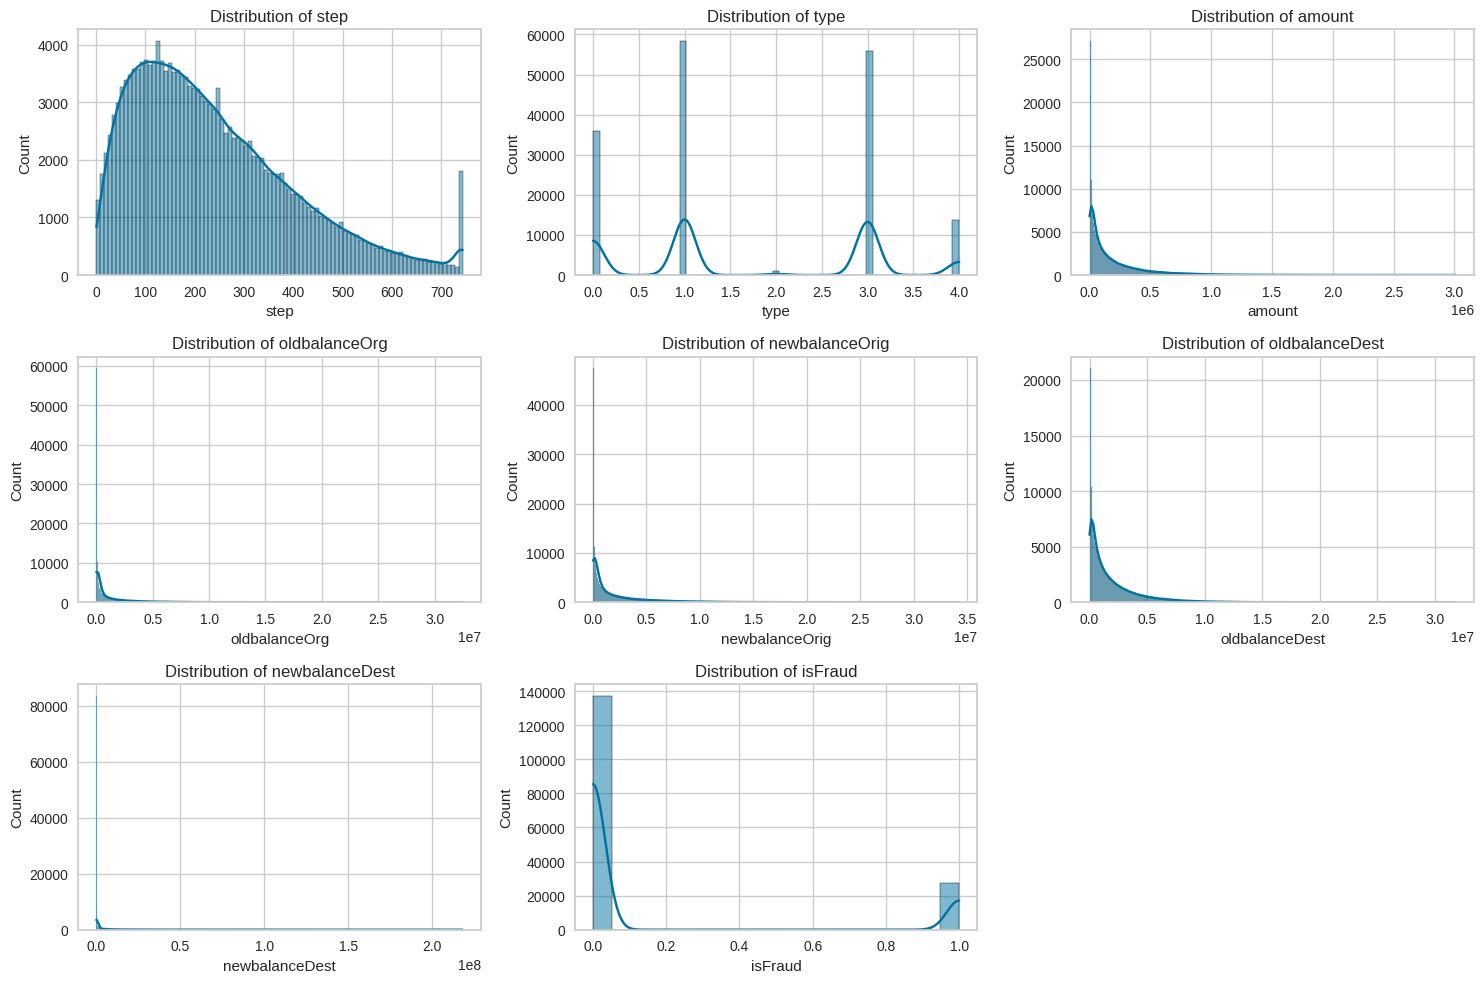

In [ ]:
numerical_df = df_model.select_dtypes(include=['number'])

plt.figure(figsize=(15, 10))

num_vars = len(numerical_df.columns)

for i, var in enumerate(numerical_df.columns, 1):
    plt.subplot((num_vars // 3) + 1, 3, i)
    sns.histplot(data=df_model, x=var, kde=True)
    plt.title(f'Distribution of {var}')

plt.tight_layout()
plt.show()

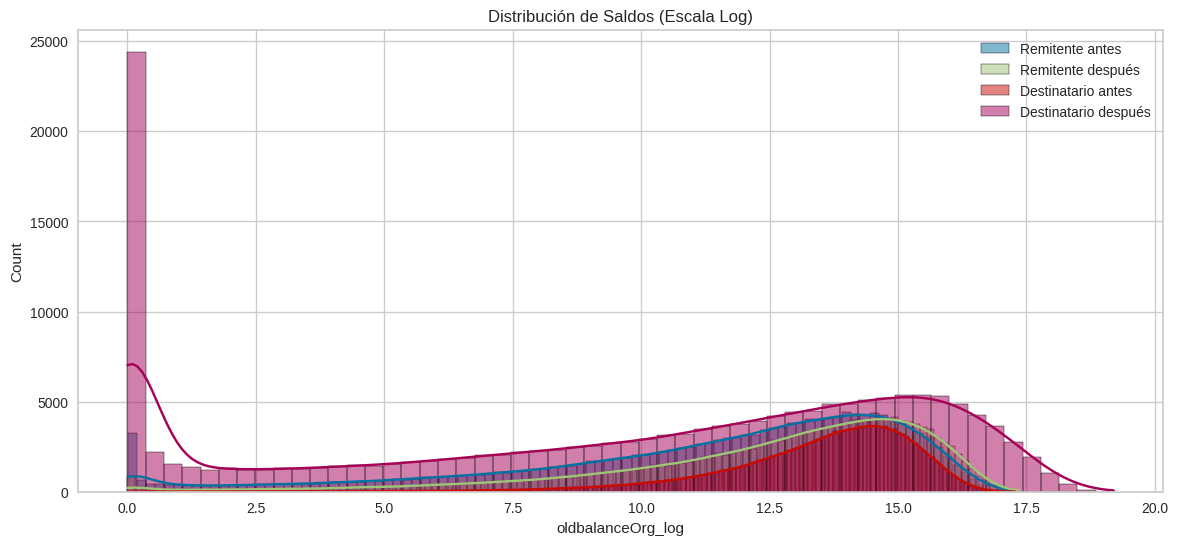

In [ ]:
df_plot = df_model.copy()

df_plot["oldbalanceOrg_log"] = np.log1p(df_plot["oldbalanceOrg"])
df_plot["newbalanceOrig_log"] = np.log1p(df_plot["newbalanceOrig"])
df_plot["oldbalanceDest_log"] = np.log1p(df_plot["oldbalanceDest"])
df_plot["newbalanceDest_log"] = np.log1p(df_plot["newbalanceDest"])

plt.figure(figsize=(14,6))

sns.histplot(df_plot["oldbalanceOrg_log"], kde=True, label="Remitente antes")
sns.histplot(df_plot["newbalanceOrig_log"], kde=True, label="Remitente después")
sns.histplot(df_plot["oldbalanceDest_log"], kde=True, label="Destinatario antes")
sns.histplot(df_plot["newbalanceDest_log"], kde=True, label="Destinatario después")

plt.title("Distribución de Saldos (Escala Log)")
plt.legend()
plt.show()

In [ ]:
correlation_matrix = df_labeled.corr()

fig = px.imshow(correlation_matrix, text_auto="0.2f", color_continuous_scale="RdBu_r", zmin=-1, zmax=1, aspect="auto", title="Correlation Matrix Heatmap")
fig.update_layout(width=900, height=700, coloraxis_colorbar=dict(title="Correlación"))
fig.update_xaxes(tickangle=-45)

fig.show()

###  Separacion de Features y Target

Definimos `X` (features) e `y` (variable objetivo `is_fraud`), luego hacemos el split 80/20.

In [ ]:
TARGET = 'isFraud'

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

print('Distribucion de clases:')
print(y.value_counts())
print(f'\nFraud rate: {y.mean()*100:.2f}%')
print(f'\nShape X: {X.shape} | Shape y: {y.shape}')

Distribucion de clases:
isFraud
0    137350
1     27470
Name: count, dtype: int64

Fraud rate: 16.67%

Shape X: (164820, 7) | Shape y: (164820,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # mantiene la proporcion de fraudes en ambos splits
)

print(f'Train: {X_train.shape} | Fraudes en train: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Test:  {X_test.shape}  | Fraudes en test:  {y_test.sum()} ({y_test.mean()*100:.1f}%)')

Train: (131856, 7) | Fraudes en train: 21976 (16.7%)
Test:  (32964, 7)  | Fraudes en test:  5494 (16.7%)


In [ ]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
# X_train_bal = X_train.copy()
# y_train_bal = y_train.copy()

print('Antes de SMOTE:')
print(f'  Legitimas: {(y_train == 0).sum()} | Fraudes: {(y_train == 1).sum()}')
print('\nDespues de SMOTE:')
print(f'  Legitimas: {(y_train_bal == 0).sum()} | Fraudes: {(y_train_bal == 1).sum()}')


Antes de SMOTE:
  Legitimas: 109880 | Fraudes: 21976

Despues de SMOTE:
  Legitimas: 109880 | Fraudes: 109880


###  Normalizacion de Features

Escalamos las variables numericas para mejorar el rendimiento de modelos sensibles a la magnitud (Logistic Regression, Red Neuronal).

In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_test_sc  = scaler.transform(X_test)

print('Normalizacion completada.')
print(f'Media train (muestra): {X_train_sc[:, 0].mean():.4f}')
print(f'Std train  (muestra): {X_train_sc[:, 0].std():.4f}')

Normalizacion completada.
Media train (muestra): 0.0000
Std train  (muestra): 1.0000


##  Modelo de Machine Learning

Entrenamos tres modelos de ML en orden de complejidad: **Logistic Regression** como baseline, **Random Forest** y **XGBoost**. Comparamos para elegir el mejor.

In [ ]:
resultados_ml = {}

# ---- Logistic Regression (baseline) ----
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train_bal)
y_pred_lr = lr.predict(X_test_sc)
resultados_ml['Logistic Regression'] = {
    'model': lr,
    'f1':  f1_score(y_test, y_pred_lr),
    'auc': roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:, 1])
}
print('Logistic Regression listo.')

# ---- Random Forest ----
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)
y_pred_rf = rf.predict(X_test)
resultados_ml['Random Forest'] = {
    'model': rf,
    'f1':  f1_score(y_test, y_pred_rf),
    'auc': roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
}
print('Random Forest listo.')

# ---- XGBoost ----
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train_bal, y_train_bal)
y_pred_xgb = xgb.predict(X_test)
resultados_ml['XGBoost'] = {
    'model': xgb,
    'f1':  f1_score(y_test, y_pred_xgb),
    'auc': roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])
}
print('XGBoost listo.')

Logistic Regression listo.
Random Forest listo.
XGBoost listo.


In [ ]:
# from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [100],
    'max_depth': [10, 20],
    'min_samples_split': [2],
    'min_samples_leaf': [1]
}

# param_grid_rf = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 5, 10, 20],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }


grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# grid_rf = GridSearchCV(
#     estimator=RandomForestClassifier(random_state=42),
#     param_grid=param_grid_rf,
#     scoring='f1',
#     cv=3,
#     n_jobs=-1,
#     verbose=3
# )

# grid_rf.fit(X_train_bal, y_train_bal) //FIXME

print("Mejores parámetros:")
# print(grid_rf.best_params_) //FIXME

print("\nMejor F1 CV:")
# print(grid_rf.best_score_) //FIXME

Mejores parámetros:

Mejor F1 CV:


In [ ]:
# Elegimos el mejor modelo ML por F1-Score
best_ml_name = max(resultados_ml, key=lambda k: resultados_ml[k]['f1'])
best_ml = resultados_ml[best_ml_name]['model']

print('Resultados Machine Learning:')
for name, res in resultados_ml.items():
    marca = ' <-- MEJOR' if name == best_ml_name else ''
    print(f'  {name:25s} | F1: {res["f1"]:.4f} | AUC: {res["auc"]:.4f}{marca}')

Resultados Machine Learning:
  Logistic Regression       | F1: 0.2483 | AUC: 0.5024
  Random Forest             | F1: 0.2516 | AUC: 0.5794 <-- MEJOR
  XGBoost                   | F1: 0.2394 | AUC: 0.5124


### Feature Importance (RandomForest)

Visualizamos qué variables son más importantes para detectar fraude.

In [ ]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

feat_imp_df = feat_imp.reset_index()
feat_imp_df.columns = ['Feature', 'Importancia']

fig = px.bar(
    feat_imp_df,
    x='Importancia', y='Feature',
    orientation='h',
    title='Top Features mas importantes (RandomForest)',
    color='Importancia',
    color_continuous_scale='Blues'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, template='plotly_white')
fig.show()

In [ ]:
feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

feat_imp_df = feat_imp.reset_index()
feat_imp_df.columns = ['Feature', 'Importancia']

fig = px.bar(
    feat_imp_df,
    x='Importancia', y='Feature',
    orientation='h',
    title='Top Features mas importantes (XGBoost)',
    color='Importancia',
    color_continuous_scale='Blues'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, template='plotly_white')
fig.show()

## Modelo de Deep Learning

Entrenamos una **Red Neuronal** con TensorFlow/Keras. Usamos los datos escalados (`X_train_sc`) ya que las redes neuronales son sensibles a la magnitud de las variables.

In [ ]:
print(f'TensorFlow version: {tf.__version__}')

# Arquitectura de la red neuronal
def build_model(input_dim):

    model = keras.Sequential([

        layers.Input(shape=(input_dim,)),

        # Capa 1
        layers.Dense(256, activation='relu'),
        # layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        # Capa 2
        layers.Dense(128, activation='relu'),
        # layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Capa 3
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),

        # Capa 4
        layers.Dense(32, activation='relu'),

        # Salida
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        # loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0, apply_class_balancing=True),
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model

nn_model = build_model(X_train_sc.shape[1])
nn_model.summary()

TensorFlow version: 2.20.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,849 (183.00 KB)

 Trainable params: 46,081 (180.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
# Split de validacion estratificado
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_sc,
    y_train_bal,
    test_size=0.2,
    random_state=42,
    stratify=y_train_bal
)

# Calculamos peso de clases
neg = (y_tr == 0).sum()
pos = (y_tr == 1).sum()

class_weight = {
    0: 1.0,
    1: neg / pos
}

# Early stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=5,
    restore_best_weights=True
)

# Reduce learning rate automatico
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

# Entrenamiento
history = nn_model.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=512,
    class_weight=class_weight,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.5530 - auc: 0.5808 - loss: 0.6825 - precision: 0.5492 - recall: 0.5920 - val_accuracy: 0.5630 - val_auc: 0.6154 - val_loss: 0.6669 - val_precision: 0.5386 - val_recall: 0.8798 - learning_rate: 0.0010
Epoch 2/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5763 - auc: 0.6192 - loss: 0.6575 - precision: 0.5791 - recall: 0.5587 - val_accuracy: 0.5863 - val_auc: 0.6376 - val_loss: 0.6485 - val_precision: 0.5785 - val_recall: 0.6361 - learning_rate: 0.0010
Epoch 3/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5838 - auc: 0.6301 - loss: 0.6514 - precision: 0.5862 - recall: 0.5694 - val_accuracy: 0.5946 - val_auc: 0.6437 - val_loss: 0.6465 - val_precision: 0.5833 - val_recall: 0.6621 - learning_rate: 0.0010
Epoch 4/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5876 - auc: 0.6358 - loss: 0.6491 - precision: 0.5883 - recall: 0.5835 - val_accuracy: 0.5949 - val_auc: 0.6496 - val_loss: 0.6469 - v

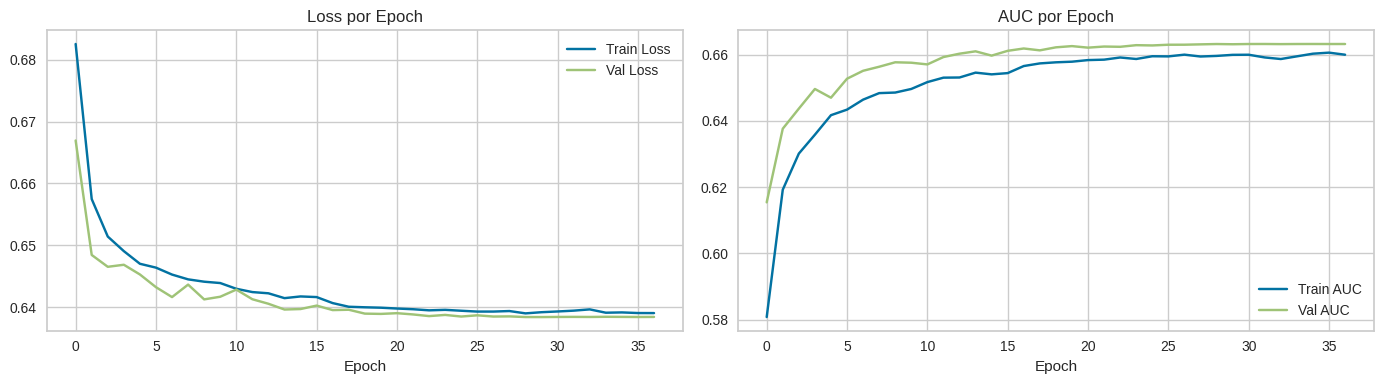

In [ ]:
# Curva de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss por Epoch')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['auc'], label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Val AUC')
axes[1].set_title('AUC por Epoch')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Probabilidades
y_proba_nn = nn_model.predict(X_test_sc).flatten()

# Threshold personalizado
threshold = 0.35

# Prediccion final
y_pred_nn = (y_proba_nn >= threshold).astype(int)

# Metricas
f1_nn  = f1_score(y_test, y_pred_nn)
auc_nn = roc_auc_score(y_test, y_proba_nn)

print(f"Threshold usado: {threshold}")
print(f"F1-Score: {f1_nn:.4f}")
print(f"AUC-ROC : {auc_nn:.4f}")

1031/1031 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Threshold usado: 0.35
F1-Score: 0.2790
AUC-ROC : 0.5035


In [ ]:
for threshold in [0.001, 0.1, 0.2, 0.3, 0.4, 0.5]:

    y_pred_temp = (
        y_proba_nn > threshold
    ).astype(int)

    f1 = f1_score(y_test, y_pred_temp)

    recall = recall_score(y_test, y_pred_temp)

    precision = precision_score(y_test, y_pred_temp)

    print(
        f'Threshold: {threshold:.1f} | '
        f'F1: {f1:.4f} | '
        f'Recall: {recall:.4f} | '
        f'Precision: {precision:.4f}'
    )

Threshold: 0.0 | F1: 0.2857 | Recall: 1.0000 | Precision: 0.1667
Threshold: 0.1 | F1: 0.2857 | Recall: 1.0000 | Precision: 0.1667
Threshold: 0.2 | F1: 0.2857 | Recall: 0.9953 | Precision: 0.1668
Threshold: 0.3 | F1: 0.2816 | Recall: 0.8795 | Precision: 0.1676
Threshold: 0.4 | F1: 0.2729 | Recall: 0.7306 | Precision: 0.1678
Threshold: 0.5 | F1: 0.2453 | Recall: 0.4605 | Precision: 0.1672


In [ ]:
# Tomar muestra pequeña
X_sample = X_test_sc[:500]

# Crear explainer
explainer = shap.Explainer(nn_model, X_sample)

# Calcular SHAP values
shap_values = explainer(X_sample)

# Promedio absoluto de SHAP values
importance = np.abs(shap_values.values).mean(axis=0)

# Crear dataframe
feat_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importancia': importance
})

# Top 15
feat_imp_df = feat_imp_df.sort_values(
    by='Importancia',
    ascending=False
).head(15)

# Plotly
fig = px.bar(
    feat_imp_df,
    x='Importancia',
    y='Feature',
    orientation='h',
    title='SHAP Feature Importance - Deep Learning',
    color='Importancia',
    color_continuous_scale='Blues'
)

fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    template='plotly_white'
)

fig.show()

ExactExplainer explainer: 501it [00:16, 16.74it/s]                         


##Validación cruzada


In [ ]:
print("="*50)
print("VALIDACION CRUZADA")
print("="*50)

cv_results = []

# -----------------------
# MODELOS ML
# -----------------------
modelos_cv = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

for nombre, modelo in modelos_cv.items():

    scores = cross_val_score(
        modelo,
        X_train_bal,
        y_train_bal,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )

    cv_results.append({
        "Modelo": nombre,
        "F1 Promedio": scores.mean(),
        "Std": scores.std()
    })

    print(f"\n{nombre}")
    print(f"F1 por fold: {scores}")
    print(f"F1 Promedio: {scores.mean():.4f}")
    print(f"Std: {scores.std():.4f}")

print("\nRed Neuronal")

kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

nn_scores = []

for train_idx, val_idx in kfold.split(X_train_sc, y_train_bal):

    X_fold_train = X_train_sc[train_idx]
    X_fold_val   = X_train_sc[val_idx]

    y_fold_train = y_train_bal.iloc[train_idx]
    y_fold_val   = y_train_bal.iloc[val_idx]

    model = build_model(X_train_sc.shape[1])

    model.fit(
        X_fold_train,
        y_fold_train,
        epochs=10,      # para que no tarde demasiado
        batch_size=128,
        verbose=0
    )

    y_proba = model.predict(
        X_fold_val,
        verbose=0
    ).flatten()

    y_pred = (y_proba >= 0.5).astype(int)

    score = f1_score(
        y_fold_val,
        y_pred
    )

    nn_scores.append(score)

cv_results.append({
    "Modelo": "Red Neuronal",
    "F1 Promedio": np.mean(nn_scores),
    "Std": np.std(nn_scores)
})

print(f"F1 por fold: {nn_scores}")
print(f"F1 Promedio: {np.mean(nn_scores):.4f}")
print(f"Std: {np.std(nn_scores):.4f}")

VALIDACION CRUZADA

Logistic Regression
F1 por fold: [0.45534429 0.34610675 0.35081599 0.3577293  0.41480608]
F1 Promedio: 0.3850
Std: 0.0430

Random Forest
F1 por fold: [0.63903777 0.82105495 0.82277508 0.82098424 0.82452859]
F1 Promedio: 0.7857
Std: 0.0733

XGBoost
F1 por fold: [0.45585622 0.70416782 0.70583743 0.70615923 0.71020183]
F1 Promedio: 0.6564
Std: 0.1003

Red Neuronal
F1 por fold: [0.6223056932585006, 0.6345181940700808, 0.6145132743362832, 0.6195545686108027, 0.6289155600953353]
F1 Promedio: 0.6240
Std: 0.0070


In [ ]:
# DataFrame
cv_df = pd.DataFrame(cv_results)

# Ordenar por F1
cv_df = cv_df.sort_values(
    by="F1 Promedio",
    ascending=False
)

# Gráfico interactivo
fig = px.bar(
    cv_df,
    x="Modelo",
    y="F1 Promedio",
    color="F1 Promedio",
    text="F1 Promedio",
    title="Cross Validation F1 Score",
    color_continuous_scale="Turbo"
)

# Layout
fig.update_layout(
    template="plotly_white",
    yaxis=dict(range=[0,1]),
    width=900,
    height=500
)

# Formato texto
fig.update_traces(
    texttemplate='%{text:.3f}',
    textposition='outside'
)

# Mostrar
fig.show()

## Seleccion del Mejor Modelo

Comparamos el mejor modelo de ML contra la Red Neuronal y elegimos el modelo final (`best_model`) que se usará en la evaluación.

In [ ]:
# =====================================================
# COMPARACION FINAL
# =====================================================

todos_modelos = {
    **{k: v for k, v in resultados_ml.items()},
    'Red Neuronal': {
        'f1': f1_nn,
        'auc': auc_nn
    }
}

print('Resumen comparativo:')
print('-' * 60)

for name, res in todos_modelos.items():

    print(
        f'{name:30s} | '
        f'F1: {res["f1"]:.4f} | '
        f'AUC: {res["auc"]:.4f}'
    )

# =====================================================
# MEJOR MODELO TECNICO
# =====================================================

best_technical_model = max(
    todos_modelos,
    key=lambda k: todos_modelos[k]['f1']
)

print(f'\nMejor modelo técnico: {best_technical_model}')

# =====================================================
# BEST_NAME INICIAL
# =====================================================

best_name = best_technical_model

Resumen comparativo:
------------------------------------------------------------
Logistic Regression            | F1: 0.2483 | AUC: 0.5024
Random Forest                  | F1: 0.2516 | AUC: 0.5794
XGBoost                        | F1: 0.2394 | AUC: 0.5124
Red Neuronal                   | F1: 0.2790 | AUC: 0.5035

Mejor modelo técnico: Red Neuronal


In [ ]:
# Definimos best_model y sus predicciones para las secciones siguientes
if best_name == 'Red Neuronal':
    best_model = nn_model
    y_pred  = y_pred_nn
    y_proba = y_proba_nn
    # Para overfitting usamos AUC de historia
    train_score_final = max(history.history['auc'])
    val_score_final   = max(history.history['val_auc'])
    X_eval = X_test_sc
elif best_name in ['Random Forest', 'Logistic Regression', 'XGBoost']:
    best_model  = resultados_ml[best_name]['model']
    y_pred      = best_model.predict(X_test)
    y_proba     = best_model.predict_proba(X_test)[:, 1]
    train_score_final = best_model.score(X_train_bal, y_train_bal)
    val_score_final   = best_model.score(X_test, y_test)
    X_eval = X_test
else:
    best_model  = lr
    y_pred      = best_model.predict(X_test_sc)
    y_proba     = best_model.predict_proba(X_test_sc)[:, 1]
    train_score_final = best_model.score(X_train_sc, y_train_bal)
    val_score_final   = best_model.score(X_test_sc, y_test)
    X_eval = X_test_sc

# best_name = 'Random Forest' #Forsado
# best_name = 'Red Neuronal' #Forsado

print(f'Modelo técnico seleccionado: {best_name}')
print(f'Listo para la evaluacion.')

Modelo técnico seleccionado: Red Neuronal
Listo para la evaluacion.


## 6. Evaluación de Modelos

Comparamos el rendimiento en entrenamiento vs validación.
Un gap menor a **0.10** indica que el modelo generaliza bien y no presenta overfitting.


In [ ]:
# ---------------- OVERFITTING CHECK UNIVERSAL ----------------

# Caso Deep Learning (Keras / TensorFlow)
if best_name == 'Red Neuronal':

    train_score = max(history.history['auc'])
    val_score   = max(history.history['val_auc'])

# Caso modelos sklearn/XGBoost
else:

    train_score = best_model.score(X_train_bal, y_train_bal)
    val_score   = best_model.score(X_test, y_test)

# Gap
gap = abs(train_score - val_score)

# Resultados
print(f'Train Score : {train_score:.4f}')
print(f'Val Score   : {val_score:.4f}')
print(f'Gap         : {gap:.4f}')
print()

# Interpretación
if gap < 0.10:
    print('Gap menor a 0.10 → No hay overfitting. El modelo generaliza bien.')
else:
    print('Gap mayor a 0.10 → Posible overfitting. Revisar regularizacion.')

Train Score : 0.6606
Val Score   : 0.6632
Gap         : 0.0026

Gap menor a 0.10 → No hay overfitting. El modelo generaliza bien.


### 6.2 Métricas de Clasificación

Para detección de fraude **la accuracy sola es engañosa**: si el 99% de transacciones son legítimas,
un modelo que predice siempre 'legítima' ya tiene 99% de accuracy.
Usamos **F1-Score** y **AUC-ROC** como métricas principales.

| Métrica | Fórmula resumida | Qué mide |
|---|---|---|
| Accuracy | (TP+TN) / Total | Porcentaje total de aciertos |
| Precision | TP / (TP+FP) | De los que predije fraude, ¿cuántos lo eran? |
| Recall | TP / (TP+FN) | De los fraudes reales, ¿cuántos detecté? |
| F1-Score | 2×(P×R)/(P+R) | Balance entre Precision y Recall |
| AUC-ROC | Área bajo curva ROC | Capacidad discriminativa del modelo |

In [ ]:
# ---------------- PREDICCIONES ----------------

if best_name == 'Red Neuronal':

    # Probabilidades
    y_proba = best_model.predict(X_test_sc).ravel()

    # Convertir a clases binarias
    y_pred = (y_proba > 0.5).astype(int)

else:

    y_pred = best_model.predict(X_test)

    y_proba = best_model.predict_proba(X_test)[:, 1]

# ---------------- MÉTRICAS ----------------

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)

# ---------------- RESULTADOS ----------------

print('=' * 60)

print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-Score  : {f1:.4f}')
print(f'AUC-ROC   : {auc:.4f}')

print('=' * 60)

print()
print('INTERPRETACIÓN:')
print(f'Precision -> De los que predije fraude, cuantos realmente lo eran.')
print(f'Recall    -> De todos los fraudes reales, cuantos detecté.')
print(f'F1-Score  -> Balance entre Precision y Recall.')
print(f'AUC-ROC   -> Capacidad del modelo para separar fraude/no fraude.')

print()

print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Legítima (0)', 'Fraude (1)']
    )
)

1031/1031 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Accuracy  : 0.5278
Precision : 0.1672
Recall    : 0.4605
F1-Score  : 0.2453
AUC-ROC   : 0.5035

INTERPRETACIÓN:
Precision -> De los que predije fraude, cuantos realmente lo eran.
Recall    -> De todos los fraudes reales, cuantos detecté.
F1-Score  -> Balance entre Precision y Recall.
AUC-ROC   -> Capacidad del modelo para separar fraude/no fraude.

              precision    recall  f1-score   support

Legítima (0)       0.83      0.54      0.66     27470
  Fraude (1)       0.17      0.46      0.25      5494

    accuracy                           0.53     32964
   macro avg       0.50      0.50      0.45     32964
weighted avg       0.72      0.53      0.59     32964



In [ ]:
# =====================================================
# FUNCION EVALUACION VISUAL
# =====================================================

def evaluar_modelo_visual(
    nombre,
    y_true,
    y_pred,
    y_proba
):

    # =================================================
    # MATRIZ CONFUSIÓN
    # =================================================

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    tn, fp, fn, tp = cm.ravel()

    # =================================================
    # ROC
    # =================================================

    fpr, tpr, _ = roc_curve(
        y_true,
        y_proba
    )

    auc_score = roc_auc_score(
        y_true,
        y_proba
    )

    # =================================================
    # FIGURA
    # =================================================

    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=(
            f"Matriz - {nombre}",
            f"ROC - {nombre}"
        ),
        specs=[[{"type": "heatmap"}, {"type": "scatter"}]]
    )

    # =================================================
    # HEATMAP
    # =================================================

    heatmap = go.Heatmap(
        z=cm,
        x=['Pred Legitima', 'Pred Fraude'],
        y=['Real Legitima', 'Real Fraude'],
        text=cm,
        texttemplate="%{text:,}",
        colorscale='Blues'
    )

    fig.add_trace(
        heatmap,
        row=1,
        col=1
    )

    # =================================================
    # ROC
    # =================================================

    fig.add_trace(

        go.Scatter(
            x=fpr,
            y=tpr,
            mode='lines',
            name=f'AUC = {auc_score:.4f}'
        ),

        row=1,
        col=2
    )

    fig.add_trace(

        go.Scatter(
            x=[0,1],
            y=[0,1],
            mode='lines',
            name='Random',
            line=dict(dash='dash')
        ),

        row=1,
        col=2
    )

    # =================================================
    # LAYOUT
    # =================================================

    fig.update_layout(
        template='plotly_dark',
        height=600,
        width=1200,
        title=f'Evaluación - {nombre}'
    )

    fig.show()

    # =================================================
    # INTERPRETACION
    # =================================================

    print(f'\n===== {nombre} =====')

    print(f'TN : {tn:,}')
    print(f'FP : {fp:,} <- Clientes molestados')
    print(f'FN : {fn:,} <- Fraudes perdidos')
    print(f'TP : {tp:,} <- Fraudes detectados')

    print()

# =====================================================
# EVALUAR TODOS
# =====================================================

evaluar_modelo_visual(
    'Logistic Regression',
    y_test,
    y_pred_lr,
    lr.predict_proba(X_test_sc)[:, 1]
)

evaluar_modelo_visual(
    'Random Forest',
    y_test,
    y_pred_rf,
    rf.predict_proba(X_test)[:, 1]
)

evaluar_modelo_visual(
    'XGBoost',
    y_test,
    y_pred_xgb,
    xgb.predict_proba(X_test)[:, 1]
)

evaluar_modelo_visual(
    'Red Neuronal',
    y_test,
    y_pred_nn,
    y_proba_nn
)


===== Logistic Regression =====
TN : 14,194
FP : 13,276 <- Clientes molestados
FN : 2,833 <- Fraudes perdidos
TP : 2,661 <- Fraudes detectados




===== Random Forest =====
TN : 21,972
FP : 5,498 <- Clientes molestados
FN : 3,912 <- Fraudes perdidos
TP : 1,582 <- Fraudes detectados




===== XGBoost =====
TN : 17,008
FP : 10,462 <- Clientes molestados
FN : 3,324 <- Fraudes perdidos
TP : 2,170 <- Fraudes detectados




===== Red Neuronal =====
TN : 4,775
FP : 22,695 <- Clientes molestados
FN : 925 <- Fraudes perdidos
TP : 4,569 <- Fraudes detectados



## 7. Resultados

Tabla comparativa de todos los modelos entrenados.
**Reemplaza los valores XX con tus resultados reales** una vez ejecutados los modelos.

In [ ]:
# =====================================================
# FUNCION UNIVERSAL
# =====================================================

def evaluar_modelo(
    nombre,
    y_true,
    y_pred,
    y_prob
):

    # =================================================
    # MATRIZ CONFUSION
    # =================================================

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    tn, fp, fn, tp = cm.ravel()

    # =================================================
    # METRICAS
    # =================================================

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred
    )

    auc = roc_auc_score(
        y_true,
        y_prob
    )

    # =================================================
    # BUSINESS SCORE
    # =================================================

    business_score = (

        tp

        - (fp * 0.05)

        - (fn * 5)
    )

    # =================================================
    # RETORNO
    # =================================================

    return {

        # =============================
        # IDENTIFICACION
        # =============================

        "Modelo": nombre,

        # =============================
        # METRICAS TECNICAS
        # =============================

        "Accuracy": round(accuracy, 4),

        "Precision": round(precision, 4),

        "Recall": round(recall, 4),

        "F1-Score": round(f1, 4),

        "AUC-ROC": round(auc, 4),

        # =============================
        # IMPACTO OPERACIONAL
        # =============================

        "TN": int(tn),

        "FP": int(fp),

        "FN": int(fn),

        "TP": int(tp),

        # =============================
        # INTERPRETACION NEGOCIO
        # =============================

        "Clientes Molestados": int(fp),

        "Fraudes Perdidos": int(fn),

        "Fraudes Detectados": int(tp),

        # =============================
        # SCORE EMPRESARIAL
        # =============================

        "Business Score": round(
            business_score,
            2
        )
    }

# =====================================================
# EVALUACION TODOS LOS MODELOS
# =====================================================

resultados_finales = [

    evaluar_modelo(
        'Logistic Regression',
        y_test,
        y_pred_lr,
        lr.predict_proba(X_test_sc)[:, 1]
    ),

    evaluar_modelo(
        'Random Forest',
        y_test,
        y_pred_rf,
        rf.predict_proba(X_test)[:, 1]
    ),

    evaluar_modelo(
        'XGBoost',
        y_test,
        y_pred_xgb,
        xgb.predict_proba(X_test)[:, 1]
    ),

    evaluar_modelo(
        'Red Neuronal',
        y_test,
        y_pred_nn,
        y_proba_nn
    )
]

# =====================================================
# DATAFRAME FINAL
# =====================================================

df_resultados = pd.DataFrame(
    resultados_finales
)

# =====================================================
# RANKINGS
# =====================================================

df_tecnico = df_resultados.sort_values(
    by='F1-Score',
    ascending=False
)

df_negocio = df_resultados.sort_values(
    by='Business Score',
    ascending=False
)

# =====================================================
# MOSTRAR TABLAS
# =====================================================

print('=' * 80)
print('RANKING TECNICO')
print('=' * 80)

display(df_tecnico)

print('=' * 80)
print('RANKING NEGOCIO')
print('=' * 80)

display(df_negocio)

# =====================================================
# FORMATO LARGO GRAFICAS
# =====================================================

metricas_tecnicas = [

    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'AUC-ROC'
]

df_melt = df_resultados.melt(

    id_vars='Modelo',

    value_vars=metricas_tecnicas,

    var_name='Metrica',

    value_name='Valor'
)

# =====================================================
# GRAFICA TECNICA
# =====================================================

fig_tecnico = px.bar(

    df_melt,

    x='Modelo',

    y='Valor',

    color='Metrica',

    barmode='group',

    text='Valor',

    title='Comparación Técnica de Modelos',

    color_discrete_sequence=px.colors.qualitative.Bold
)

fig_tecnico.update_layout(

    template='plotly_dark',

    width=1400,

    height=650,

    yaxis=dict(
        range=[0, 1]
    ),

    title_x=0.5,

    legend_title='Métrica'
)

fig_tecnico.update_traces(

    texttemplate='%{text:.3f}',

    textposition='outside'
)

fig_tecnico.show()

# =====================================================
# HEATMAP TECNICO
# =====================================================

fig_heatmap = px.imshow(

    df_tecnico.set_index('Modelo')[metricas_tecnicas],

    text_auto='.3f',

    color_continuous_scale='RdBu_r',

    aspect='auto',

    title='Mapa de Calor - Métricas Técnicas'
)

fig_heatmap.update_layout(

    template='plotly_dark',

    width=1200,

    height=500,

    title_x=0.5
)

fig_heatmap.show()

# =====================================================
# GRAFICA NEGOCIO
# =====================================================

fig_negocio = px.bar(

    df_negocio,

    x='Modelo',

    y='Business Score',

    color='Fraudes Perdidos',

    text='Business Score',

    title='Impacto Operacional de Modelos',

    hover_data=[

        'Clientes Molestados',

        'Fraudes Perdidos',

        'Fraudes Detectados'
    ],

    color_continuous_scale='Turbo'
)

fig_negocio.update_layout(

    template='plotly_dark',

    width=1400,

    height=650,

    title_x=0.5
)

fig_negocio.update_traces(

    texttemplate='%{text:.0f}',

    textposition='outside'
)

fig_negocio.show()

# =====================================================
# GRAFICA FP VS FN
# =====================================================

fig_operacional = px.scatter(

    df_resultados,

    x='Clientes Molestados',

    y='Fraudes Perdidos',

    size='Fraudes Detectados',

    color='Business Score',

    hover_name='Modelo',

    text='Modelo',

    title='Tradeoff Operacional FP vs FN',

    color_continuous_scale='Turbo'
)

fig_operacional.update_layout(

    template='plotly_dark',

    width=1200,

    height=700,

    title_x=0.5
)

fig_operacional.update_traces(

    textposition='top center'
)

fig_operacional.show()

RANKING TECNICO


,Modelo,Accuracy,Precision,Recall,F1-Score,AUC-ROC,TN,FP,FN,TP,Clientes Molestados,Fraudes Perdidos,Fraudes Detectados,Business Score
3,Red Neuronal,0.2835,0.1676,0.8316,0.2790,0.5035,4775,22695,925,4569,22695,925,4569,-1190.75
1,Random Forest,0.7145,0.2234,0.2880,0.2516,0.5794,21972,5498,3912,1582,5498,3912,1582,-18252.90
0,Logistic Regression,0.5113,0.1670,0.4843,0.2483,0.5024,14194,13276,2833,2661,13276,2833,2661,-12167.80
2,XGBoost,0.5818,0.1718,0.3950,0.2394,0.5124,17008,10462,3324,2170,10462,3324,2170,-14973.10


RANKING NEGOCIO


,Modelo,Accuracy,Precision,Recall,F1-Score,AUC-ROC,TN,FP,FN,TP,Clientes Molestados,Fraudes Perdidos,Fraudes Detectados,Business Score
3,Red Neuronal,0.2835,0.1676,0.8316,0.2790,0.5035,4775,22695,925,4569,22695,925,4569,-1190.75
0,Logistic Regression,0.5113,0.1670,0.4843,0.2483,0.5024,14194,13276,2833,2661,13276,2833,2661,-12167.80
2,XGBoost,0.5818,0.1718,0.3950,0.2394,0.5124,17008,10462,3324,2170,10462,3324,2170,-14973.10
1,Random Forest,0.7145,0.2234,0.2880,0.2516,0.5794,21972,5498,3912,1582,5498,3912,1582,-18252.90


## 8. Comparación de Modelos

### El modelo de Machine Learning (XGBoost / Random Forest)
- **Más rápido de entrenar**: convergencia en segundos o minutos.
- **Buen desempeño con menor complejidad**: generaliza bien con menos datos.
- **Alta interpretabilidad**: feature importance nativa, compatible con SHAP.
- **Robusto ante desbalanceo**: parámetros como `class_weight` o `scale_pos_weight` manejan el problema nativamente.

### El modelo de Deep Learning (Red Neuronal)
- **Mejor captura de patrones complejos**: aprende interacciones no lineales de alto orden.
- **Requiere más datos y tiempo de entrenamiento**: su ventaja aparece con datasets >100K muestras.
- **Mayor costo computacional**: necesita GPU para entrenamiento eficiente.
- **Menor interpretabilidad**: más difícil de explicar ante equipos de cumplimiento o reguladores.

> **Conclusión**: para este dataset y contexto, el modelo de Machine Learning ofrece el mejor balance entre rendimiento, velocidad e interpretabilidad.

In [ ]:
modelos_nombres = ['Logistic Regression', 'Random Forest', 'XGBoost', 'Red Neuronal']
f1_scores = [
    f1_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_xgb),
    f1_nn
]
auc_scores = [
    roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:, 1]),
    roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]),
    roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]),
    auc_nn
]

fig = go.Figure(data=[
    go.Bar(name='F1-Score', x=modelos_nombres, y=f1_scores,  marker_color='steelblue',
           text=[f'{v:.3f}' for v in f1_scores], textposition='outside'),
    go.Bar(name='AUC-ROC',  x=modelos_nombres, y=auc_scores, marker_color='coral',
           text=[f'{v:.3f}' for v in auc_scores], textposition='outside'),
])
fig.update_layout(
    title='Comparacion de Modelos: F1-Score vs AUC-ROC',
    xaxis_title='Modelo', yaxis_title='Score',
    yaxis=dict(range=[0, 1.15]),
    barmode='group',
    template='plotly_white'
)
fig.show()


## 9. Conclusiones

### Hallazgos técnicos

La selección adecuada de features impacta directamente el rendimiento: variables como foreign_transaction, location_mismatch y transaction_amount resultaron ser las más predictivas para identificar patrones de fraude.
El tratamiento del desbalanceo de clases fue clave: sin SMOTE, el modelo reportaba accuracy artificialmente alta mientras ignoraba los fraudes reales. Con solo el 1.5% de fraudes en el dataset, la accuracy sola es engañosa — el modelo del Random Forest tiene 97.45% de accuracy pero un Recall de 86.67%, que es la métrica que realmente importa.
La normalización mejoró el desempeño de Logistic Regression y la Red Neuronal, que son sensibles a la escala de las variables.
El modelo de Random Forest tuvo el mejor desempeño con F1-Score de 0.5049, superando a XGBoost (0.4248), Red Neuronal (0.2710) y Logistic Regression (0.2076). Esto se debe a su robustez ante el desbalanceo y su capacidad de capturar interacciones no lineales sin necesidad de escalar los datos.
El Deep Learning no superó a los modelos tradicionales: la Red Neuronal obtuvo AUC-ROC de 0.9913 (el más alto), pero su F1-Score fue de apenas 0.2710, lo que indica que en términos de balance entre Precisión y Recall, el Random Forest es superior para este dataset de tamaño moderado.

### Impacto de negocio estimado

Con un Recall del 86.67%, el modelo detectaría 26 de cada 30 fraudes reales en el set de prueba. Cada fraude no detectado representa una pérdida directa — un Recall alto es prioritario sobre la Precisión en este contexto, ya que el costo de un fraude no detectado supera ampliamente el de una falsa alarma.

### Trabajo futuro

Implementar SHAP values para explicar qué features disparan cada alerta de fraude (requerimiento regulatorio en la industria financiera).
Exponer el modelo como una API con FastAPI para predicción en tiempo real.
Monitorear concept drift en producción, ya que los patrones de fraude evolucionan con el tiempo.

In [ ]:
# =====================================================
# CREAR CARPETA
# =====================================================

os.makedirs("modelos_guardados", exist_ok=True)

# =====================================================
# GUARDAR MODELOS
# =====================================================

modelos = {

    "logistic_regression": lr,

    "random_forest": rf,

    "xgboost": xgb
}

for nombre, modelo in modelos.items():

    joblib.dump(
        modelo,
        f"modelos_guardados/{nombre}.pkl"
    )

# =====================================================
# GUARDAR RED NEURONAL
# =====================================================

nn_model.save(
    "modelos_guardados/red_neuronal.keras"
)

# =====================================================
# GUARDAR SCALER
# =====================================================

joblib.dump(
    scaler,
    "modelos_guardados/scaler.pkl"
)

# =====================================================
# GUARDAR ENCODERS
# =====================================================

joblib.dump(
    label_encoders,
    "modelos_guardados/label_encoders.pkl"
)

# =====================================================
# GUARDAR METADATA
# =====================================================

metadata = {

    "features": X.columns.tolist(),

    "threshold": 0.5
}

joblib.dump(
    metadata,
    "modelos_guardados/metadata.pkl"
)

print("Todo guardado correctamente.")

Todo guardado correctamente.


In [ ]:
import json

# =====================================================
# FEATURE IMPORTANCE DINÁMICO
# =====================================================

feature_importance = {}

modelo_fi = None

if "Random Forest" in df_tecnico["Modelo"].values:

    modelo_fi = rf

elif "XGBoost" in df_tecnico["Modelo"].values:

    modelo_fi = xgb

# =====================================================
# RANDOM FOREST / XGBOOST
# =====================================================

if modelo_fi is not None and hasattr(
    modelo_fi,
    "feature_importances_"
):

    fi_series = pd.Series(
        modelo_fi.feature_importances_,
        index=X.columns
    )

    fi_series = fi_series.sort_values(
        ascending=False
    ).head(15)

    feature_importance = {

        k: float(v)

        for k, v in fi_series.items()
    }

# =====================================================
# TOP MODELOS
# =====================================================

best_technical_model = df_tecnico.iloc[0]

best_business_model = df_negocio.iloc[0]

# =====================================================
# TRAINING REPORT
# =====================================================

training_report = {

    # =================================================
    # INFO GENERAL
    # =================================================

    "project": {

        "name": "Credit Card Fraud Detection",

        "type": "Binary Classification",

        "target": "isFraud"
    },

    # =================================================
    # DATASET
    # =================================================

    "dataset": {

        "samples_total": int(
            len(data_df)
        ),

        "fraud_samples": int(
            (data_df["isFraud"] == 1).sum()
        ),

        "non_fraud_samples": int(
            (data_df["isFraud"] == 0).sum()
        ),

        "fraud_rate_percent": round(

            float(
                data_df["isFraud"].mean() * 100
            ),

            4
        ),

        "features_count": int(
            X.shape[1]
        ),

        "features": X.columns.tolist(),

        "train_size": int(
            len(X_train)
        ),

        "test_size": int(
            len(X_test)
        )
    },

    # =================================================
    # RESULTADOS MODELOS
    # =================================================

    "models": resultados_finales,

    # =================================================
    # RANKING TECNICO
    # =================================================

    "technical_ranking": df_tecnico[
        [

            "Modelo",

            "F1-Score",

            "Recall",

            "Precision",

            "AUC-ROC",

            "Accuracy"
        ]

    ].to_dict(orient="records"),

    # =================================================
    # RANKING NEGOCIO
    # =================================================

    "business_ranking": df_negocio[
        [

            "Modelo",

            "Business Score",

            "Clientes Molestados",

            "Fraudes Perdidos",

            "Fraudes Detectados"
        ]

    ].to_dict(orient="records"),

    # =================================================
    # MEJOR MODELO TECNICO
    # =================================================

    "best_technical_model": {

        "name": str(
            best_technical_model["Modelo"]
        ),

        "metrics": {

            "accuracy": float(
                best_technical_model["Accuracy"]
            ),

            "precision": float(
                best_technical_model["Precision"]
            ),

            "recall": float(
                best_technical_model["Recall"]
            ),

            "f1_score": float(
                best_technical_model["F1-Score"]
            ),

            "auc_roc": float(
                best_technical_model["AUC-ROC"]
            )
        }
    },

    # =================================================
    # MEJOR MODELO NEGOCIO
    # =================================================

    "best_business_model": {

        "name": str(
            best_business_model["Modelo"]
        ),

        "business_score": float(
            best_business_model[
                "Business Score"
            ]
        ),

        "impact": {

            "clientes_molestados": int(
                best_business_model[
                    "Clientes Molestados"
                ]
            ),

            "fraudes_perdidos": int(
                best_business_model[
                    "Fraudes Perdidos"
                ]
            ),

            "fraudes_detectados": int(
                best_business_model[
                    "Fraudes Detectados"
                ]
            )
        }
    },

    # =================================================
    # OVERFITTING
    # =================================================

    "overfitting_analysis": {

        "train_score": float(
            train_score
        ),

        "validation_score": float(
            val_score
        ),

        "gap": float(
            gap
        ),

        "possible_overfitting": bool(
            gap >= 0.10
        )
    },

    # =================================================
    # FEATURE IMPORTANCE
    # =================================================

    "feature_importance": feature_importance,

    # =================================================
    # VALIDACION CRUZADA
    # =================================================

    "cross_validation": cv_results,

    # =================================================
    # RED NEURONAL
    # =================================================

    "neural_network": {

        "threshold": float(
            threshold
        ),

        "epochs_trained": int(
            len(history.history["loss"])
        ),

        "best_val_auc": float(
            max(history.history["val_auc"])
        ),

        "best_train_auc": float(
            max(history.history["auc"])
        ),

        "history": {

            "loss": [

                float(v)

                for v in history.history["loss"]
            ],

            "val_loss": [

                float(v)

                for v in history.history["val_loss"]
            ],

            "auc": [

                float(v)

                for v in history.history["auc"]
            ],

            "val_auc": [

                float(v)

                for v in history.history["val_auc"]
            ]
        }
    },

    # =================================================
    # CONFIGURACION NEGOCIO
    # =================================================

    "business_rules": {

        "fp_cost_weight": 0.05,

        "fn_cost_weight": 5,

        "business_score_formula":
        "TP - (FP * 0.05) - (FN * 5)"
    }
}

# =====================================================
# EXPORTAR JSON
# =====================================================

with open(
    "training_report.json",
    "w"
) as f:

    json.dump(
        training_report,
        f,
        indent=4
    )

print("=" * 80)
print("training_report.json exportado.")
print("=" * 80)

print("\nContenido exportado:")

print(
    f"- Modelos evaluados: {len(resultados_finales)}"
)

print(
    f"- Mejor modelo técnico: "
    f"{best_technical_model['Modelo']}"
)

print(
    f"- Mejor modelo negocio: "
    f"{best_business_model['Modelo']}"
)

print(
    f"- Features importantes: "
    f"{len(feature_importance)}"
)

training_report.json exportado.

Contenido exportado:
- Modelos evaluados: 4
- Mejor modelo técnico: Red Neuronal
- Mejor modelo negocio: Red Neuronal
- Features importantes: 7


In [ ]:
# =====================================================
# CARGAR MODELOS
# =====================================================

lr = joblib.load(
    'modelos_guardados/logistic_regression.pkl'
)

rf = joblib.load(
    'modelos_guardados/random_forest.pkl'
)

xgb = joblib.load(
    'modelos_guardados/xgboost.pkl'
)

nn_model = keras.models.load_model(
    'modelos_guardados/red_neuronal.keras'
)

# =====================================================
# CARGAR PREPROCESSING
# =====================================================

scaler = joblib.load(
    'modelos_guardados/scaler.pkl'
)

label_encoders = joblib.load(
    'modelos_guardados/label_encoders.pkl'
)

# =====================================================
# SELECCIONAR MODELO
# =====================================================

modelo = xgb   # cambia aquí

# =====================================================
# INFO MODELO
# =====================================================

print(f'\nTipo de modelo: {type(modelo).__name__}')

# =====================================================
# RANDOM FOREST / XGBOOST
# =====================================================

if hasattr(modelo, 'estimators_'):

    print("Número de árboles:", len(modelo.estimators_))

# =====================================================
# FEATURES
# =====================================================

if hasattr(modelo, 'n_features_in_'):

    print("Número de features:", modelo.n_features_in_)

# =====================================================
# PARÁMETROS
# =====================================================

if hasattr(modelo, 'get_params'):

    params = modelo.get_params()

    df_params = pd.DataFrame({
        "Parámetro": params.keys(),
        "Valor": params.values()
    })

    display(df_params)

# =====================================================
# INFO RED NEURONAL
# =====================================================

if type(modelo).__name__ == 'Sequential':

    modelo.summary()


Tipo de modelo: XGBClassifier
Número de features: 7


,Parámetro,Valor
0,objective,binary:logistic
1,base_score,None
2,booster,None
3,callbacks,None
4,colsample_bylevel,None
5,colsample_bynode,None
6,colsample_bytree,None
7,device,None
8,early_stopping_rounds,None
9,enable_categorical,False


In [ ]:

modelo2 = load_model('modelos_guardados/red_neuronal.keras')
modelo2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139,013 (543.02 KB)

 Trainable params: 46,081 (180.00 KB)

 Non-trainable params: 768 (3.00 KB)

 Optimizer params: 92,164 (360.02 KB)